# My Notes

- **Course**: Qubits, entanglement and matrix product sates
- **Author**: Théo HUET
- **Date**: 30/01/2026 - 13/02/2026

# TD2 - Matrix Product State

## Exercice 3 : SVD truncation / MPS intution



In [47]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import constants
from utils import *

In [48]:
N = 200

A = random_complexe_matrix(N,N) # random matrix de taille NxN
A = normalisation(A) # normalisation de la matrice

print("||A||² =", norm2(A).round(2))
print("Trace(AA^{dagger}) =", trace(A @ np.transpose(np.conjugate(A))).round(2).real)


||A||² = 1.0
Trace(AA^{dagger}) = 1.0


We have indeed generated a complex matrix $A$ that represents a normalized state because $||A||^2 = 1$.

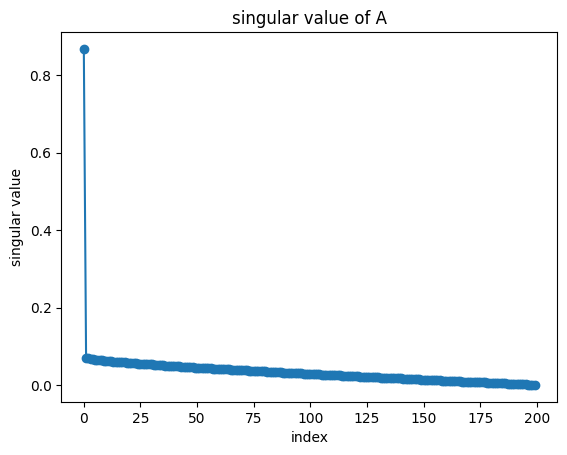

sum singular_value² = 1.0


In [49]:
U, s, Vh = svd(A)

# note : s = si = scipy.linalg.svdvals(A) # calcul les singular value

plt.figure()
plt.plot(s, 'o-')
plt.title("singular value of A")
plt.xlabel("index")
plt.ylabel("singular value")
plt.show()

print("sum singular_value² =", np.sum(s**2).round(2))

We can clearly see that the singular values of our matrix $A$ decrease very quickly to $0$.

We will therefore set a “threshold”: $ds = 0.01$ such that any singular value below this threshold will be removed.

We just need to check whether you are keeping your: $\Sigma_{i}s_i^2 = 1$

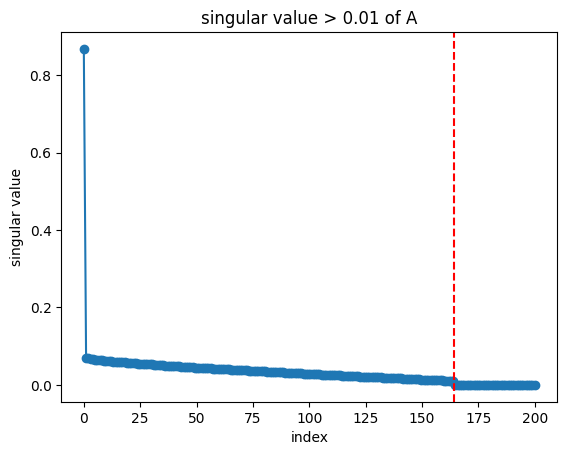

sum singular_value > 0.01)² = 1.0


In [50]:
ds = 0.01

sp = s * (s>ds) # on garde seulement les si > 0.01 on met a 0 les autres

i = np.argmin(sp) # pour savoir ou l'on retire des singular values graphiquement
x = np.linspace(0,N,N)

plt.figure()
plt.plot(x, sp, 'o-')
plt.axvline(x=i,color='red',linestyle='--')
plt.title(f"singular value > {ds} of A")
plt.xlabel("index")
plt.ylabel("singular value")
plt.show()
print(f"sum singular_value > {ds})² =", np.sum(sp**2).round(2))

We can see that even if we remove the values below our ‘threshold’ (to the right of the red line), this changes very little in terms of our problem, because we still have: $\Sigma_{s_i>0.1}s_i^2 \approx 1$.

In [51]:
Ap = dot((U * sp), Vh)

print("||A - Ap|| =", (np.linalg.norm(A - Ap)/N).round(5), "<", ds)
print("||A - Ap||² =", (norm2(A - Ap)).round(5), f"= sum (singular_value > {ds})² =", (np.sum((s * (s<ds))**2)).round(5))

||A - Ap|| = 0.00017 < 0.01
||A - Ap||² = 0.00121 = sum (singular_value > 0.01)² = 0.00121


The method is very stable, we have $\frac{||A-A'||}{N} < 0.01$.

Here $\frac{||A-A'||}{N} \approx 0.0002$.

And we have $||A-A'||^2 \approx \Sigma_{s_i<0.1}s_i^2$.

This shows us that our change does not alter the problem, but greatly simplifies it. We will use this later.

## Exercice 4 : 2-Qubit Heisenberg ground state as an MPS

The anti-ferromagnetic Hamiltonian of Two Qubits :
$H = J(\sigma_1^x \sigma_2^x + \sigma_1^y \sigma_2^y + \sigma_1^z \sigma_2^z) = J \vec\sigma_1.\vec\sigma_2 \quad$ and $\quad J = 1$

In [52]:
def compute_H(J : float, nbr_qubit : int) :
  if nbr_qubit == 2 :
    return J*(np.kron(constants.X, constants.X) + np.kron(constants.Y, constants.Y) + np.kron(constants.Z, constants.Z))
  elif nbr_qubit == 3 :
    return J*(np.kron(np.kron(constants.X, constants.X),constants.I) + np.kron(np.kron(constants.Y, constants.Y),constants.I) + np.kron(np.kron(constants.Z, constants.Z),constants.I)) + J*(np.kron(np.kron(constants.I, constants.X),constants.X) + np.kron(np.kron(constants.I, constants.Y),constants.Y) + np.kron(np.kron(constants.I, constants.Z),constants.Z))

In [53]:
J = 1.
nbr_qubit = 2

H = compute_H(J, nbr_qubit)

E0, v0 = ground_state(H)

print("E0 =", E0)
print("v0 = ", v0.real.round(3), "\nwith 1/sqrt(2) =", (1/np.sqrt(2)).round(3))

E0 = [-3.]
v0 =  [[ 0.   ]
 [ 0.094]
 [-0.094]
 [ 0.   ]] 
with 1/sqrt(2) = 0.707


Ground state :

$E_0 = -3\quad$ and $\quad v_0 = \frac{|01> -|10>}{\sqrt2}$.

Because $v_0 = (0 \quad \frac{1}{\sqrt2} \quad -\frac{1}{\sqrt2} \quad 0) $ in the base $|00>, |01>, |10>, |11>$.

In [54]:
vM = v0.reshape((2,2))

U, s, Vh = svd(vM)

print("U =\n", U)
print("s =\n", s)
print("Vh =\n", Vh)

U =
 [[ 1.32639325e-01-9.91164371e-01j  0.00000000e+00-5.51985630e-17j]
 [-1.11022302e-16+5.55111512e-17j  1.32639325e-01-9.91164371e-01j]]
s =
 [0.70710678 0.70710678]
Vh =
 [[ 0.+0.j  1.+0.j]
 [-1.+0.j -0.+0.j]]


### Output 1

<img src="https://github.com/TheoHUETQC/qubits-entanglement-matrix-product-states/blob/main/td/figure/c_plus_minus.png?raw=1" width="300" alt="MPS à deux sites">

In [55]:
A, B = U, np.diag(s)@Vh

norm = mps_norm(A, B)

c = np.einsum('sk,kS,sm,Sn,ml,ln->', A, B, constants.SP,constants.SM, A.conj(), B.conj())

print("Output 1 :")
print("norm =", norm.round(2))
print("c+- =",c.round(2).real, "= -1/2")

Output 1 :
norm = 1.0
c+- = -0.5 = -1/2


The anti-ferromagnetic Hamiltonian of **Three Qubits** :

$H = J \vec\sigma_1.\vec\sigma_2 + J \vec\sigma_2.\vec\sigma_3 \quad$ and $\quad J = 1$

In [56]:
J = 1
nbr_qubit = 3

H = compute_H(J, nbr_qubit)

E0, v0 = ground_state(H)

vR = v0.reshape((2,4))

# first SVD
U, s, Vh = svd(vR)

A, M = U, np.diag(s) @ Vh
#M = M.reshape((2,2,2))     # (a, σ₂, σ₃)
# second SVD
Up, sp, Vhp = svd(M.reshape((4,2))) # M : (aσ₂, σ₃)

B = Up.reshape((2,2,2))    # (a, σ₂, b)
C = np.diag(sp) @ Vhp      # (b, σ₃)

In [57]:
print("A :\n", A)
print("B :\n", B)
print("C :\n", C)

norm = np.einsum('sa,akb,bl,is,skj,jl->',
                  A.conj(), B.conj(), C.conj(),
                  A, B, C)                          # verification

print("\nnorm :", norm.real.round(2))

A :
 [[-0.50877156+1.21978545e-17j  0.86090156+2.43957091e-17j]
 [-0.80583248+3.02961243e-01j -0.4762271 +1.79042613e-01j]]
B :
 [[[ 6.99693562e-01+3.21481128e-01j -4.62308863e-01-2.12412380e-01j]
  [-4.53910032e-01-3.23185151e-02j -8.58727661e-01-6.11416380e-02j]]

 [[ 2.06750809e-01+9.49937042e-02j  1.06685494e-16+6.93889390e-18j]
  [ 3.84034685e-01+2.73433718e-02j -1.56125113e-16+1.24900090e-16j]]]
C :
 [[-0.46444277+0.j         -0.73562104+0.27656451j]
 [-0.35146159+0.j          0.1944189 -0.07309384j]]

norm : 0.53


### Output 2

<img src="https://github.com/TheoHUETQC/qubits-entanglement-matrix-product-states/blob/main/td/figure/c_plus_id_minus.png?raw=1" width="400" alt="MPS à trois sites">

In [58]:
c = np.einsum('Sa,akb,bm,sS,ml,is,jki,lj->',
              A.conj(), B.conj(), C.conj(),
              constants.SP, constants.SM,
              A, B, C)

print("c+id- :", c)

c+id- : (0.022230610431007235+0.05644217724283719j)


need to be $\approx 0.1666\dots$

---

## Exercice 5 : Imaginary-time evolutionfor the 2-site ground state

We use imaginary-time evolution to compute the ground state :
$$ |GS \rangle = \lim_{t \rightarrow \infty }\frac{e^{-tH}|\Psi_0 \rangle}{||e^{-tH}|\Psi_0 \rangle ||} \quad \text{with} \quad |\Psi_0 \rangle = |01 \rangle$$

In [59]:
state0 = np.array([1, 0], dtype=complex)
state1 = np.array([0, 1], dtype=complex)
psi0 = np.kron(state0, state1)

vR = psi0.reshape(2,2)

U, s, Vh = svd(vR)

print("U =\n", U)
print("s =\n", s)
print("Vh =\n", Vh)

U =
 [[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
s =
 [1. 0.]
Vh =
 [[ 0.+0.j  1.+0.j]
 [-1.+0.j  0.+0.j]]


Une valeur singulière = 0, on a donc "bond dimension = 1".

The hamiltonian in this exercice :
$$ H = XX+YY+ZZ$$

Evolution operator :
$$G = e^{-\delta \tau H} \quad \text{with} \quad \delta \tau = 0.1$$

In [60]:
from scipy.linalg import expm

H = np.kron(constants.X, constants.X) + np.kron(constants.Y, constants.Y) + np.kron(constants.Z,constants.Z)
HR = H.reshape(2,2,2,2)

GR = expm(-constants.dt*HR)

def compute_E(A: np.array, B: np.array, HR: np.array) -> float : # <H>
  return np.einsum('sk,kS,sSlL,lm,mL->', A.conj(), B.conj(), HR, A, B).real

def evolution_psi(A : np.array, B: np.array, GR: np.array) -> np.array :
  psi = np.einsum('ijsS, sk, kS->ij', GR, A, B)
  return psi

def mps(psi: np.array) -> tuple[np.array, np.array]:
  psiR = psi.reshape(2,2) # pas utile.. ici
  U, s, Vh = svd(psiR)
  s /= np.sqrt(np.sum(s**2)) # normalisation car l'évolution n'est pas unitaire
  return U, np.diag(s)@Vh, s

In [61]:
def simulation(Nt : int) :
  E, S = [], []
  psi = psi0.reshape(2,2)
  for i in range(Nt) :
    A, B, s = mps(psi)
    assert np.abs(np.linalg.norm(A@B) - 1) < constants.epsilon # check the norm
    psi = evolution_psi(A, B, GR)

    E.append(compute_E(A, B, HR))
    S.append(measurements_entropy_SVD(s))
  return E, S

### Output :

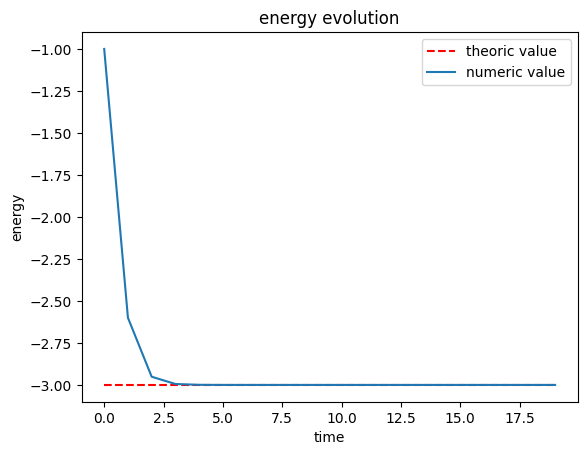

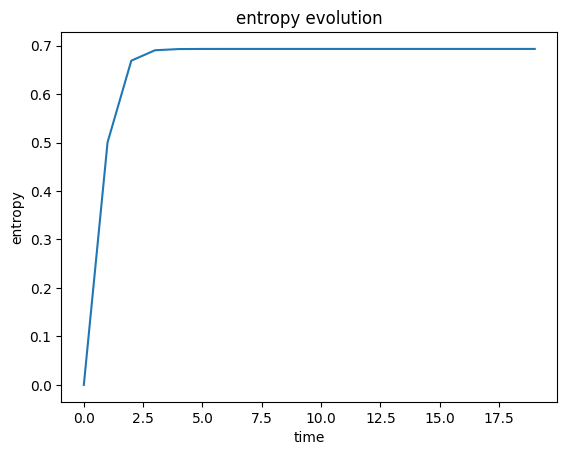

In [62]:
E, S = simulation(20)

plt.figure()
plt.hlines(-3, 0, 19, color='red', linestyles='--', label='theoric value')
plt.plot(E, label='numeric value')
plt.title("energy evolution")
plt.xlabel("time")
plt.ylabel("energy")
plt.legend()
plt.show()

plt.figure()
plt.plot(S, label='numeric value')
plt.title("entropy evolution")
plt.xlabel("time")
plt.ylabel("entropy")
plt.show()

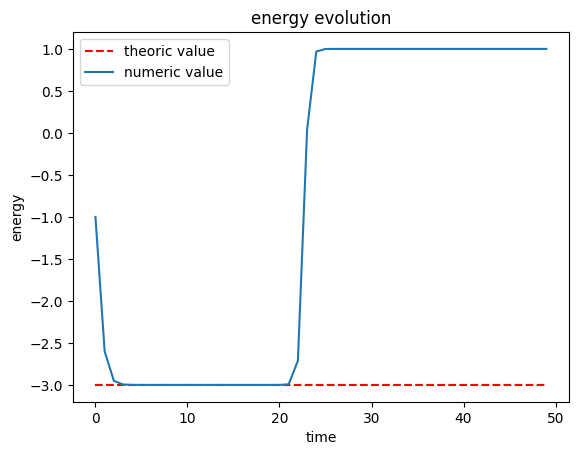

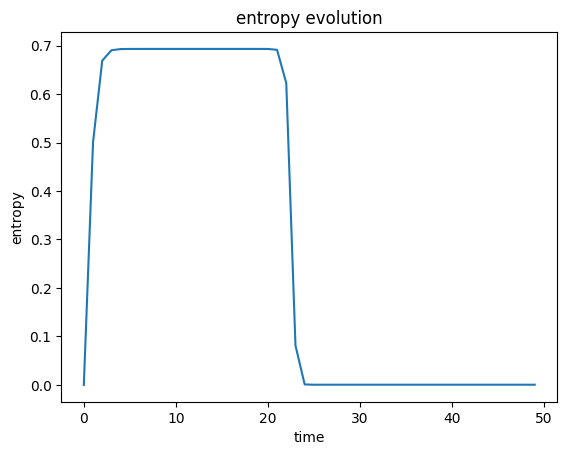

In [63]:
E, S = simulation(50)

plt.figure()
plt.hlines(-3, 0, 49, color='red', linestyles='--', label='theoric value')
plt.plot(E, label='numeric value')
plt.title("energy evolution")
plt.xlabel("time")
plt.ylabel("energy")
plt.legend()
plt.show()

plt.figure()
plt.plot(S, label='numeric value')
plt.title("entropy evolution")
plt.xlabel("time")
plt.ylabel("entropy")
plt.show()

Au dela de $\approx 20$ la méthode n'est plus stable

---

## Exercice 6 : iTEBD for the ising chain

$$H = - \Sigma_j (\sigma_j^x\sigma_{j+1}^x + h \sigma_j^z) = \Sigma_j h_{j,j+1}$$

$$h_{j,j+1} = - \sigma_j^x \sigma_{j+1}^x - \frac{h}{2}(\sigma_j^z I_{j+1} + I_j \sigma_{j+1}^z) $$

In [104]:
import numpy as np

# ----------------------------
# Basic operators (spin-1/2)
# ----------------------------
I2 = np.array([[1, 0], [0, 1]], dtype=complex)
sx = np.array([[0, 1], [1, 0]], dtype=complex)
sy = np.array([[0, -1j], [1j, 0]], dtype=complex)
sz = np.array([[1, 0], [0, -1]], dtype=complex)

sp = 0.5 * (sx + 1j * sy)   # sigma^+
sm = 0.5 * (sx - 1j * sy)   # sigma^-

In [206]:
from numpy.linalg import inv
def gate_ising_two_site(h: float, delta: float): # delta = delta tau
    """
    Build the imaginary-time two-site gate G = exp(-delta * h2)
    with h2 = -sx⊗sx - (h/2)(sz⊗I + I⊗sz).
    Returns:
      G4 : shape (2,2,2,2) with indices (s1', s2', s1, s2)
      h2_4 : same shape for measuring energy <h2>
    """
    h2 = -np.kron(sx, sx) - 0.5 * h * (np.kron(sz, I2) + np.kron(I2, sz))  # 4x4 Hermitian
    w, V = np.linalg.eigh(h2)
    G = V @ np.diag(np.exp(-delta * w)) @ V.conj().T                        # 4x4
    G4 = G.reshape(2, 2, 2, 2)                                              # (s1',s2',s1,s2)
    h2_4 = h2.reshape(2, 2, 2, 2)
    return G4, h2_4

def entropy_from_lambda(lmbda: np.ndarray) -> float:
    """Entanglement entropy from Schmidt values lambda."""
    p = (np.abs(lmbda) ** 2)
    p = p[p > 0]  # avoid log(0)
    return float(-np.sum(p * np.log(p)))

def apply_two_site_gate(GammaL, lamL, lamM, GammaR, lamR, G4, chi_max=32, eps=5e-2):
    """
    One iTEBD update on a bond:
      ... --lamL-- GammaL --lamM-- GammaR --lamR-- ...
    Apply gate G4 on the two physical indices of (GammaL, GammaR),
    then restore canonical form by SVD:
      - update middle Schmidt values lamM
      - update GammaL and GammaR
    Canonical convention used here:
      theta[a,s,t,c] = lamL[a] * GammaL[a,s,b] * lamM[b] * GammaR[b,t,c] * lamR[c]
    with GammaL shape (chiL, d, chiM), GammaR shape (chiM, d, chiR).
    """
    chiL, d, chiM = GammaL.shape
    chiM2, d2, chiR = GammaR.shape
    assert d == 2 and d2 == 2
    assert chiM == chiM2
    assert lamL.shape == (chiL,)
    assert lamM.shape == (chiM,)
    assert lamR.shape == (chiR,)

    # Build theta[a,s,t,c]
    theta = np.einsum('a,asb,b,btc,c->astc', lamL, GammaL, lamM, GammaR, lamR)

    # Apply gate on physical indices (s,t) -> (s',t')
    theta_g = np.einsum('STst,astc->aSTc', G4, theta)

    # Reshape to matrix for SVD: (a,S) x (T,c)
    M = theta_g.reshape(chiL * d, d * chiR)

    U, s, Vh = np.linalg.svd(M, full_matrices=False)

     # complete the code below

    # Truncation by eps and chi_max
    chi = s[s>eps].shape[0]
    if chi > chi_max:
        chi = chi_max

    U = U[:, :chi]
    Vh = Vh[:chi, :]
    s = s[:chi]

    # Renormalise state by normalising Schmidt values (keeps norms under control)
    lamM_new = s/np.sqrt(np.sum(s**2))

    # Reshape U, Vh back to Gammas
    Ur = U.reshape(chiL, d, chi)
    Vhr = Vh.reshape(chi, d, chiR)

    # Divide out the outer lambdas to keep canonical form
    if chiL > 1:
        inv_LamL = 1/lamL
        GammaL_new = np.einsum('i, ijk->ijk',inv_LamL, Ur)
    else :
        GammaL_new = Ur/lamL

    if chiR > 1:
        inv_LamR = 1/lamR
        GammaR_new = np.einsum('ijk, k->ijk',Vhr, inv_LamR)
    else :
        GammaR_new = Vhr/lamR

    return GammaL_new, lamM_new, GammaR_new

def two_site_expectation(GammaL, lamL, lamM, GammaR, lamR, O4):
    """
    Expectation value of a two-site operator O4[s,t,s',t'] on the bond (L,R),
    using theta[a,s,t,c] as above.
    Returns <O>.
    """
    theta = np.einsum('a,asb,b,btc,c->astc', lamL, GammaL, lamM, GammaR, lamR)
    norm = np.einsum('astc,astc->', theta.conj(), theta).real
    val = np.einsum('astc,stuv,auvc->', theta.conj(), O4, theta)
    return (val / norm)

# ----------------------------
# Initial iMPS: product of singlets on AB bonds
# ----------------------------
# Unit cell ...-B-A-B-A-...
# We store: GammaA (chiBA,d,chiAB), GammaB (chiAB,d,chiBA)
# with lambdas: lamAB (between A and B), lamBA (between B and A)

def init_singlet_dimer():
    # From your sheet:
    # A_{i σ k} = δ_{i,1} [[1,0],[0,-1]]_{σ,k}
    # B_{k σ l} = [[0,1],[1,0]]_{k,σ} δ_{l,1}
    GammaA = np.zeros((1, 2, 2), dtype=complex)  # (chiBA=1, d=2, chiAB=2)
    GammaA[0, :, :] = np.array([[1, 0],
                                [0, -1]], dtype=complex)

    GammaB = np.zeros((2, 2, 1), dtype=complex)  # (chiAB=2, d=2, chiBA=1)
    GammaB[:, :, 0] = np.array([[0, 1],
                                [1, 0]], dtype=complex)

    lamAB = np.array([1/np.sqrt(2), 1/np.sqrt(2)], dtype=float)  # Schmidt on AB
    lamBA = np.array([1.0], dtype=float)                          # Schmidt on BA
    return GammaA, GammaB, lamAB, lamBA

# ----------------------------
# One TEBD "layer": AB then BA + measurements
# ----------------------------
def ite_bd_demo(h=0.5, delta=0.1, nsteps=10, chi_max=32, eps=5e-2, show_print=False):
    G4, h2_4 = gate_ising_two_site(h=h, delta=delta)

    # Operators for correlation c = <sigma^+_A sigma^-_B>
    corr_AB = np.kron(sp, sm).reshape(2, 2, 2, 2)  # (s,t,s',t')

    GammaA, GammaB, lamAB, lamBA = init_singlet_dimer()

    e_list, c_list, Sab_list, Sba_list = [], [], [], []

    for it in range(nsteps):
        # --- Gate on AB bond ---
        # structure: ... --lamBA-- A --lamAB-- B --lamBA-- ...
        GammaA, lamAB, GammaB = apply_two_site_gate(
            GammaA, lamBA, lamAB, GammaB, lamBA, G4, chi_max=chi_max, eps=eps
        )

        # --- Gate on BA bond ---
        # structure: ... --lamAB-- B --lamBA-- A --lamAB-- ...
        GammaB, lamBA, GammaA = apply_two_site_gate(
            GammaB, lamAB, lamBA, GammaA, lamAB, G4, chi_max=chi_max, eps=eps
        )

        # --- Measurements (AB and BA bonds; average them) ---
        eAB = two_site_expectation(GammaA, lamBA, lamAB, GammaB, lamBA, h2_4).real
        eBA = two_site_expectation(GammaB, lamAB, lamBA, GammaA, lamAB, h2_4).real
        e = 0.5 * (eAB + eBA)

        cAB = two_site_expectation(GammaA, lamBA, lamAB, GammaB, lamBA, corr_AB)
        cBA = two_site_expectation(GammaB, lamAB, lamBA, GammaA, lamAB, corr_AB)
        c = 0.5 * (cAB + cBA)

        Sab = entropy_from_lambda(lamAB)
        Sba = entropy_from_lambda(lamBA)

        e_list.append(e)
        c_list.append(c)
        Sab_list.append(Sab)
        Sba_list.append(Sba)

        if show_print :
          print(f"it={it:03d}  e={e:+.12f}  c={c:+.12f}  chiAB={len(lamAB)} chiBA={len(lamBA)}  S_AB={Sab:.6f} S_BA={Sba:.6f}")

    return {
        "e": np.array(e_list),
        "c": np.array(c_list),
        "S_AB": np.array(Sab_list),
        "S_BA": np.array(Sba_list),
        "GammaA": GammaA, "GammaB": GammaB, "lamAB": lamAB, "lamBA": lamBA
    }



chi_max = 10 finish
chi_max = 30 finish
chi_max = 50 finish


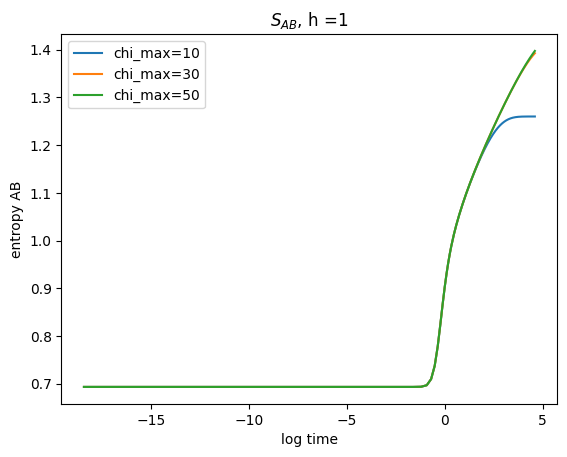

In [211]:
Nt = 1000
dt = 0.1
h = 1

chi_max_list = np.linspace(10,50, 3, dtype=int)
t = np.linspace(constants.epsilon, Nt*dt, Nt)

plt.figure()
for chi_max in chi_max_list:
  out = ite_bd_demo(h=h, delta=dt, nsteps=Nt, chi_max=chi_max, eps=1e-8)
  plt.plot(np.log(t), out["S_AB"], label="chi_max="+str(chi_max))
  #plt.plot(out["S_BA"], label="$S_{BA}$")
  print(f"chi_max = {chi_max} finish")

plt.title("$S_{AB}$, h ="+str(h))
plt.xlabel("log time")
plt.ylabel("entropy AB")
plt.legend()
plt.show()

it=000  e=+0.351751738973  c=-0.220671914538+0.000000000000j  chiAB=2 chiBA=2  S_AB=0.693147 S_BA=0.054876
it=001  e=+0.244042042605  c=-0.183023434712+0.000000000000j  chiAB=2 chiBA=2  S_AB=0.693147 S_BA=0.166885
it=002  e=+0.095594106370  c=-0.138283922435+0.000000000000j  chiAB=2 chiBA=2  S_AB=0.693147 S_BA=0.317059
it=003  e=-0.114186634111  c=-0.091260440347+0.000000000000j  chiAB=2 chiBA=2  S_AB=0.693147 S_BA=0.481167
it=004  e=-0.352285030775  c=-0.052471717026+0.000000000000j  chiAB=2 chiBA=2  S_AB=0.693147 S_BA=0.605105
it=005  e=-0.551629275418  c=-0.028394914827+0.000000000000j  chiAB=2 chiBA=2  S_AB=0.693147 S_BA=0.662600
it=006  e=-0.692685997933  c=-0.015607409358+0.000000000000j  chiAB=2 chiBA=2  S_AB=0.693147 S_BA=0.682187
it=007  e=-0.809829896702  c=-0.011260340722+0.000000000000j  chiAB=2 chiBA=3  S_AB=0.693147 S_BA=0.702750
it=008  e=-0.921424293838  c=-0.009692976388+0.000000000000j  chiAB=2 chiBA=4  S_AB=0.693147 S_BA=0.745542
it=009  e=-1.052803874562  c=-0.00604

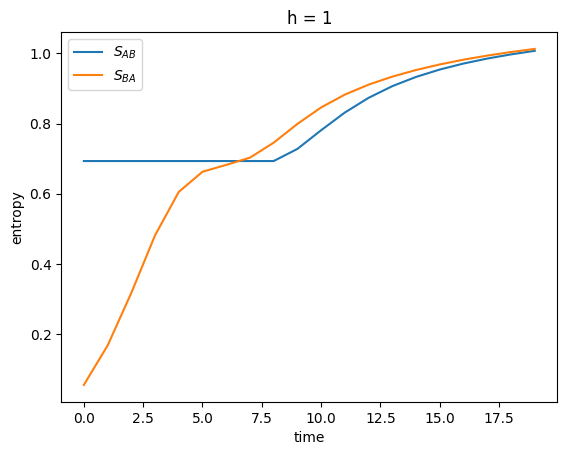

In [208]:
# Example: run a few steps (students can raise nsteps to ~100 and plot)
h = 1
Nt = 20
out = ite_bd_demo(h=h, delta=0.1, nsteps=Nt, chi_max=32, eps=0.05, show_print=True)

plt.figure()
plt.plot(out["S_AB"], label="$S_{AB}$")
plt.plot(out["S_BA"], label="$S_{BA}$")
plt.title(f"h = {h}")
plt.xlabel("time")
plt.ylabel("entropy")
plt.legend()
plt.show()